# Paleographia Digitalis  
**Automated Latin Manuscript Classification**

*Academic prototype developed for the Machine Learning for Humanities 2025/2026 course.*


This projects intent is to build a machin learning model of image recognition that allows the user to identify the typology of scripture used in medieval and latin manuscripts
This model was trained on the ICDAR CLaMM  (Classification of Latin Medieval Manuscripts) dataset, that provide 12 distinct paleographic script types in a csv. 


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# Impostazione dei path del dataset, se gli trova

DATA_DIR = "/kaggle/input/datasets/mariajgamboa/clammdst/CLaMM_DST"  
CSV_PATH = os.path.join(DATA_DIR, "/kaggle/input/datasets/mariajgamboa/clammdst/CLaMM_DST/CLaMM_Metadata.csv")

print(f"File CSV trovato: {os.path.exists(CSV_PATH)}") #check che ha trovato i file 

File CSV trovato: True


### 1. Environment Setup and Dataset Mapping
We prepare the workspace for the **CLaMM_DST** dataset (comprising 4,540 medieval manuscript page images):
- **PIL Image Loading Adjustments:** We disable the pixel limit (`MAX_IMAGE_PIXELS = None`) and enable truncated image loading to prevent errors when processing high-resolution manuscript scans.
- **Metadata Ingestion:** We read `CLaMM_Metadata.csv` directly from Kaggle  path and process the `SCRIPT_TYPE` column into a zero-indexed target `label` (`0` to `11`), for  PyTorch.
- **Dynamic File Mapping:** All image are indexed into a dictionary map (`image_map`) associating filename keys with their absolute file paths. This for constant-time ($O(1)$) file retrieval.

In [ ]:
import os, glob
import pandas as pd
import torch
from PIL import Image, ImageFile

# Prevenir errores en manuscritos  en TIFF
Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")

# Paths
DATA_DIR = "/kaggle/input/datasets/mariajgamboa/clammdst/CLaMM_DST"
CSV_PATH = os.path.join(DATA_DIR, "CLaMM_Metadata.csv")

# 1. Cargar el CSV
df = pd.read_csv(CSV_PATH, sep=None, engine='python')
df.columns = df.columns.str.strip()

# 2. Mapeo de etiquetas (SCRIPT_TYPE de 1..12 -> label de 0..11)
script_col = [col for col in df.columns if col.upper() == 'SCRIPT_TYPE'][0]
df['label'] = df[script_col].astype(int) - 1
num_classes = df['label'].nunique()

# 3. Mapeo rápido de archivos de imagen en disco
all_image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.[jJ][pP][gG]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[pP][nN][gG]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[tT][iI][fF]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[jJ][pP][eE][gG]", recursive=True)
)

image_map = {os.path.basename(p).lower(): p for p in all_image_paths}

print("\n--- RESUMEN DEL DATASET CLaMM_DST ---")
print(f"Total de registros en CSV: {len(df)}")
print(f"Total de imágenes encontradas en disco: {len(image_map)}")
print(f"Número de clases: {num_classes}")
print("\nDistribución de muestras por clase (0-11):")
print(df['label'].value_counts().sort_index())

Dispositivo activo: cuda

--- RESUMEN DEL DATASET CLaMM_DST ---
Total de registros en CSV: 4540
Total de imágenes encontradas en disco: 4540
Número de clases: 12

Distribución de muestras por clase (0-11):
label
0     507
1     538
2     230
3     216
4     238
5     399
6     541
7     297
8     347
9     219
10    784
11    224
Name: count, dtype: int64




### 2. PyTorch `CLaMMDataset` Class Definition
We create a dataset class inheriting from `torch.utils.data.Dataset` for our data loading pipeline:
- **Robust Indexing:** Accesses DataFrame records via the `FILENAME` column.
- **Extension-Tolerant Resolution:** Queries the pre-built image map with an automated fallback mechanism across standard extension variants (`.jpg`, `.jpeg`, `.tif`, `.png`) to handle format inconsistencies.
- **Image Preprocessing:** Opens the image file, converts it to the RGB color space, and applies any specified geometric or numerical transformations.
- **Output:** Returns the preprocessed image tensor with its corresponding class target (`torch.long`).

In [ ]:
from torch.utils.data import Dataset

class CLaMMDataset(Dataset):
    def __init__(self, df, image_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['FILENAME']).strip().lower()

        # Búsqueda en el mapa de imágenes
        if img_name in self.image_map:
            final_path = self.image_map[img_name]
        else:
            base_name = os.path.splitext(img_name)[0]
            matched = None
            for ext in ['.jpg', '.jpeg', '.tif', '.png']:
                if (base_name + ext) in self.image_map:
                    matched = self.image_map[base_name + ext]
                    break
            final_path = matched

        if not final_path:
            raise KeyError(f"No se encontró la imagen en disco: '{row['FILENAME']}'")

        image = Image.open(final_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(row['label'], dtype=torch.long)

print("Cella 2 lista: CLaMMDataset configurado explícitamente con 'FILENAME'.")

Cella 2 lista: CLaMMDataset configurado explícitamente con 'FILENAME'.


### 3. Data Transformation Pipeline and (`DataLoaders`)
The data loading pipeline for training and evaluating the neural network:
- **Standard Transformations:** Page images are resized to $224 \times 224$ pixels, converted to PyTorch tensors, and normalized using standard ImageNet parameters (`mean` and `std`).
- **Data Splitting (80/20 Split):** The 4,540 dataset samples are randomly partitioned using `random_split` with a fixed seed (`seed=42`) to ensure experimental reproducibility:
  - **Training Set:** 3,632 images.
  - **Validation Set:** 908 images.
- **DataLoaders:** Batches are configured with `batch_size=32` and multi-process parallel loading (`num_workers=2`)

In [4]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = CLaMMDataset(df=df, image_map=image_map, transform=train_tf)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_tf

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Cella 3 lista: {len(train_dataset)} muestras de Train | {len(val_dataset)} muestras de Val")

Cella 3 lista: 3632 muestras de Train | 908 muestras de Val


### 4. Baseline Model Training and Evaluation (ResNet18)
- **Architecture:** We load a pre-trained **ResNet18** backbone (ImageNet weights) and replace its final linear classification head (`model.fc`) to output predictions across the **12 medieval script classes**.
- **Optimization Strategy:** The network is trained using `CrossEntropyLoss` combined with the `Adam` optimizer ($\text{learning\_rate} = 10^{-4}$).
- **Training Loop (10 Epochs):**
  - **Training Phase:** Updates network parameters iteratively across each mini-batch.
  - **Validation Phase:** Evaluates model generalization on the held-out split without computing gradients (`torch.no_grad()`).
- **Checkpointing:** Automatically saves the model checkpoint (`resnet18_baseline_4540.pth`) exclusively when a new peak validation accuracy (`Val Accuracy`) is achieved.

In [5]:
import time
import torch.nn as nn
from torchvision import models

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10
best_val_acc = 0.0

print("--- Inicio de Entrenamiento Baseline ResNet18 (4,540 imágenes) ---")
start_time = time.time()

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data)
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = (correct_train.double() / total_train).item()

    # VAL
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val.double() / total_val).item()

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "resnet18_baseline_4540.pth")
        saved_mark = "[Guardado]"
    else:
        saved_mark = ""

    print(f"Época [{epoch+1:02d}/{num_epochs:02d}] | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f} {saved_mark}")

elapsed_time = (time.time() - start_time) / 60
print(f"\nEntrenamiento completado en {elapsed_time:.2f} minutos.")
print(f"Mejor Precisión de Validación: {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


--- Inicio de Entrenamiento Baseline ResNet18 (4,540 imágenes) ---
Época [01/10] | Train Loss: 1.5173 - Acc: 0.4816 | Val Loss: 1.2009 - Acc: 0.5683 [Guardado]
Época [02/10] | Train Loss: 0.8166 - Acc: 0.7208 | Val Loss: 1.2486 - Acc: 0.5595 
Época [03/10] | Train Loss: 0.4432 - Acc: 0.8733 | Val Loss: 1.2057 - Acc: 0.6068 [Guardado]
Época [04/10] | Train Loss: 0.1964 - Acc: 0.9612 | Val Loss: 1.2434 - Acc: 0.6156 [Guardado]
Época [05/10] | Train Loss: 0.0777 - Acc: 0.9920 | Val Loss: 1.2510 - Acc: 0.6355 [Guardado]
Época [06/10] | Train Loss: 0.0363 - Acc: 0.9978 | Val Loss: 1.3334 - Acc: 0.6178 
Época [07/10] | Train Loss: 0.0315 - Acc: 0.9972 | Val Loss: 1.3565 - Acc: 0.6222 
Época [08/10] | Train Loss: 0.0302 - Acc: 0.9964 | Val Loss: 1.4677 - Acc: 0.6035 
Época [09/10] | Train Loss: 0.0524 - Acc: 0.9890 | Val Loss: 1.3855 - Acc: 0.6211 
Época [10/10] | Train Loss: 0.0426 - Acc: 0.9934 | Val Loss: 1.4569 - Acc: 0.6244 

Entrenamiento completado en 29.52 minutos.
Mejor Precisión de 

### 5. Detailed Evaluation: Confusion Matrix and Per-Class Metrics
Evaluate the performance of our baseline model:
- **Checkpoint Restoration:** We reload the optimal weights saved from the best epoch (`resnet18_baseline_4540.pth`).
- **Per-Class Metrics:** We compute *Precision*, *Recall*, and *F1-Score* across all 12 classes to detect performance imbalances in underrepresented script types.
- **Confusion Matrix Visualization:** A plot: for misclassification patterns among medieval script categories (e.g., scripts sharing overlapping morphological traits) 

Evaluando el mejor modelo guardado en el conjunto de validación...

--- REPORTE DE CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

      Tipo 1     0.7519    0.8083    0.7791       120
      Tipo 2     0.5259    0.5545    0.5398       110
      Tipo 3     0.8649    0.7805    0.8205        41
      Tipo 4     0.8085    0.7170    0.7600        53
      Tipo 5     0.7736    0.9318    0.8454        44
      Tipo 6     0.3542    0.2152    0.2677        79
      Tipo 7     0.6385    0.7757    0.7004       107
      Tipo 8     0.4545    0.3390    0.3883        59
      Tipo 9     0.4773    0.3000    0.3684        70
     Tipo 10     0.5610    0.5750    0.5679        40
     Tipo 11     0.6011    0.7483    0.6667       147
     Tipo 12     0.9444    0.8947    0.9189        38

    accuracy                         0.6355       908
   macro avg     0.6463    0.6367    0.6353       908
weighted avg     0.6207    0.6355    0.6216       908



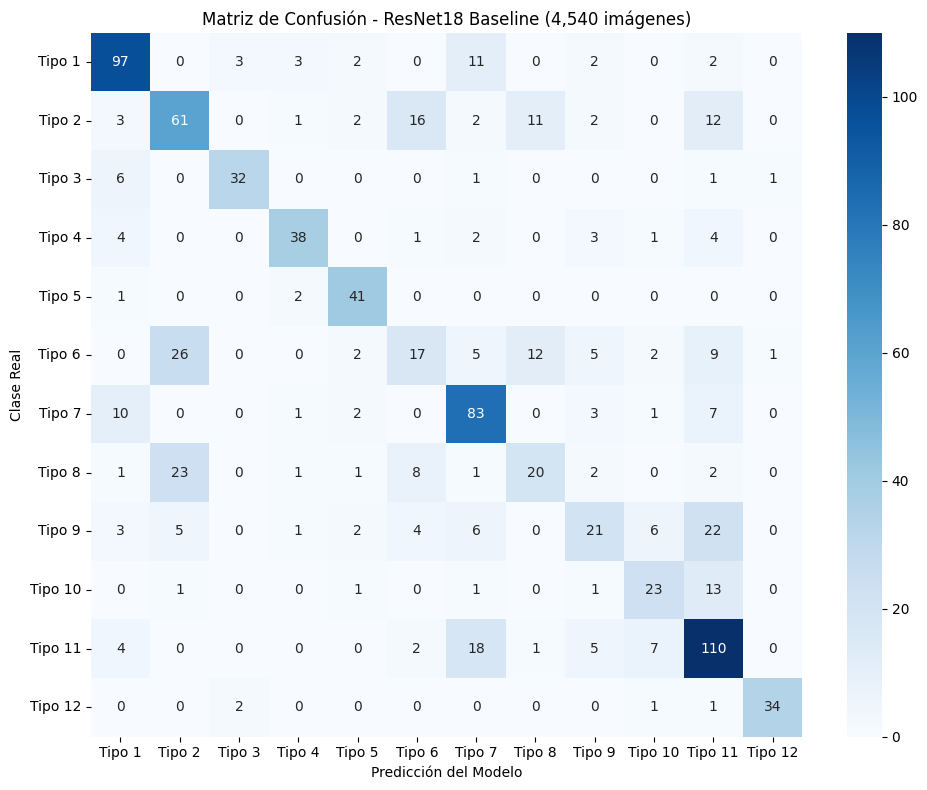

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# mejores pesos guardados
model.load_state_dict(torch.load("resnet18_baseline_4540.pth"))
model.eval()

y_true = []
y_pred = []

print("Evaluando el mejor modelo guardado en el conjunto de validación...")

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

#  Reporte  (Precision, Recall, F1)
class_names = [f"Tipo {i+1}" for i in range(num_classes)]
print("\n--- REPORTE DE CLASIFICACIÓN POR CLASE ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Dibujar Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión - ResNet18 Baseline (4,540 imágenes)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()